# Домашнее задание 1

## Импорт базовых библиотек и загрузка датасета

Данный датасет представляет собой данные с сайта Airbnb. Этот сайт предоставляет квартиры для краткосрочной аренды. В нашем случае квартиры находятся в NYC. Наш таргет будет цена квартиры (задача регрессии)

Импортируем базовые библиотеки

In [104]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [106]:
df = pd.read_csv('/work/AB_NYC_2019.csv')
df.head(5)

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


## EDA

Для начала быстро осмотрим датасет с помощью базовых команд и просто взглянув на строки датасета.

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  object 
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  object 
 4   neighbourhood_group             48895 non-null  object 
 5   neighbourhood                   48895 non-null  object 
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  object 
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non-null  int64  
 12  last_review                     

In [16]:
print(f"Всего дубликатов - {df.duplicated().astype('int').sum()}")

Всего дубликатов - 0


Первичный осмотр дал следующее:
- Всего 48895 строк
- Всего у нас 16 колонок, есть числовые и категориальные признаки
- id, name, host_id, host_name можно отсеять, хотя из последних двух признаков можно постараться сделать некий информативный признак (пол или количество комнат у хозяина, но посмотримм)
- В колонках host_name, name, last_review, reviews_per_month есть явные пропуски
- Всего дублирующих строк = 0

Хочу посмотреть на базовые статистики в датасете

In [44]:
df.describe()

,id,host_id,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
count,4.889500e+04,4.889500e+04,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000,38843.000000,48895.000000,48895.000000
mean,1.901714e+07,6.762001e+07,40.728949,-73.952170,152.720687,7.029962,23.274466,1.373221,7.143982,112.781327
std,1.098311e+07,7.861097e+07,0.054530,0.046157,240.154170,20.510550,44.550582,1.680442,32.952519,131.622289
min,2.539000e+03,2.438000e+03,40.499790,-74.244420,0.000000,1.000000,0.000000,0.010000,1.000000,0.000000
25%,9.471945e+06,7.822033e+06,40.690100,-73.983070,69.000000,1.000000,1.000000,0.190000,1.000000,0.000000
50%,1.967728e+07,3.079382e+07,40.723070,-73.955680,106.000000,3.000000,5.000000,0.720000,1.000000,45.000000
75%,2.915218e+07,1.074344e+08,40.763115,-73.936275,175.000000,5.000000,24.000000,2.020000,2.000000,227.000000
max,3.648724e+07,2.743213e+08,40.913060,-73.712990,10000.000000,1250.000000,629.000000,58.500000,327.000000,365.000000


Посмотрим, все ли уникальны значения в колонке id

In [24]:
n_unique_id = len(df['id'].unique())
print(f"Число уникальных id = {n_unique_id}")

Число уникальных id = 48895


Круто, id все уникальные

In [12]:
mismatches = (
    df.groupby("host_id")["id"].transform("count")
    .ne(df["calculated_host_listings_count"])
    .sum()
)
print(f"Всего несовпадений с количеством квартир у хозяина с calculated_host_listings_count = {mismatches}")

Всего несовпадений с количеством квартир у хозяина с calculated_host_listings_count = 0


Супер, я думала создавать отдельный признак, где будет отражаться количество квартир у хозяина, но система за меня все сделала, значит **удаляем host_id**

Изучим с чем связаны пропуски в name

In [2]:
print("Распределение разных числовых признаков, где name пропущено")
df[df['name'].isnull()].describe()

Распределение разных числовых признаков, где name пропущено


,id,host_id,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
count,1.600000e+01,1.600000e+01,16.000000,16.000000,16.000000,16.000000,16.000000,6.000000,16.000000,16.000000
mean,8.410815e+06,3.672124e+07,40.742235,-73.956065,147.625000,64.875000,2.687500,0.153333,1.312500,89.375000
std,5.385275e+06,2.423883e+07,0.057460,0.035822,102.037166,249.373582,6.973462,0.172124,1.014479,159.955775
min,1.615764e+06,1.832442e+06,40.664090,-74.016200,40.000000,1.000000,0.000000,0.020000,1.000000,0.000000
25%,4.528898e+06,2.137588e+07,40.709407,-73.989267,69.250000,1.000000,0.000000,0.032500,1.000000,0.000000
50%,8.054179e+06,3.226261e+07,40.718390,-73.947835,120.000000,2.000000,0.000000,0.080000,1.000000,0.000000
75%,1.073864e+07,4.985894e+07,40.772878,-73.930373,203.750000,4.000000,1.500000,0.225000,1.000000,85.250000
max,2.227582e+07,8.528834e+07,40.860320,-73.884930,400.000000,1000.000000,28.000000,0.450000,5.000000,365.000000


Можно заметить следующее:
- Этих строк ничтожно мало по сравнению с общим количеством строк (16 против 48895)
- Большинство объявлений - новые (нет отзывов вовсе)
- 50 процентов показывают availablity_365 = 0
- Тут есть явный выброс в minimum_nights = 1000
Решение: Пока оставлю, явных паттернов пока что нету

In [16]:
print("Распределение разных числовых признаков, где host_name пропущено")
df[df['host_name'].isnull()].describe()

Распределение разных числовых признаков, где host_name пропущено


,id,host_id,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
count,2.100000e+01,2.100000e+01,21.000000,21.000000,21.000000,21.000000,21.000000,16.000000,21.000000,21.000000
mean,1.265783e+07,6.399307e+07,40.736755,-73.947637,110.952381,3.714286,42.142857,1.811875,1.380952,83.857143
std,8.965730e+06,7.246035e+07,0.058753,0.048446,72.439959,6.466397,55.419568,2.079626,0.740013,137.209798
min,1.001840e+05,4.152900e+05,40.643450,-73.998010,28.000000,1.000000,0.000000,0.020000,1.000000,0.000000
25%,6.292866e+06,7.779204e+06,40.701460,-73.968360,55.000000,1.000000,1.000000,0.110000,1.000000,0.000000
50%,1.070985e+07,3.272206e+07,40.739490,-73.953550,100.000000,1.000000,6.000000,0.845000,1.000000,0.000000
75%,2.186771e+07,1.196093e+08,40.775870,-73.936430,139.000000,4.000000,81.000000,3.282500,1.000000,88.000000
max,3.046834e+07,2.287500e+08,40.838440,-73.761330,325.000000,30.000000,182.000000,5.970000,3.000000,359.000000


Сравнивая с статистиками всего датасета, например по number_of_reviews. Во всем датасете среднее около 42 что почти совпадает с датасетом, где host_name пропущено. И медианы почти равны. Значит, это не фейки, не боты, а нормальные люди. Значит оставляем однозначно

Проверяем с чем связаны пропуски в last_reviews и в reviews_per_month

In [26]:
null_last_review = df['last_review'].isna().astype('int').sum()
null_reviews_per_month = df['reviews_per_month'].isna().astype('int').sum()
only_one_null_in_pair = (df['last_review'].isna() != df['reviews_per_month'].isna()).astype('int').sum()
print(f"Количество строк, где last_reviews null = {null_last_review}")
print(f"Количество строк, где reviews_per_month null = {null_reviews_per_month}")
print(f"Количество строк, где из этой парочки только один null = {only_one_null_in_pair }")

Количество строк, где last_reviews null = 10052
Количество строк, где reviews_per_month null = 10052
Количество строк, где из этой парочки только один null = 0


In [28]:
n1 = df[df['number_of_reviews'] == 0]['last_review'].isna().astype('int').sum()
# .count() считает строки, игнорируя Nan
n2 = df[df['number_of_reviews'] == 0]['last_review'].count()

print(f"Количество строк, где reviews = 0 и last_review null = {n1}")
print(f"Количество строк, где reviews = 0 и last_review not null = {n2}")

Количество строк, где reviews = 0 и last_review null = 10052
Количество строк, где reviews = 0 и last_review not null = 0


Из этого можно сделать вывод, что пропуски в last_review и reviews_per_month имеют конкретное значение: number_of_reviews = 0 что значит, что отзывов не было вовсе

Изучу диапазон даты последнего отзыва

In [36]:
n_empty_datetime = df["last_review"].isna().sum()
#to_datetime приводит в Null и неправильно написанную дату и пустую
n_incorrect_datetime = pd.to_datetime(df['last_review'], errors='coerce').isna().sum() - n_empty_datetime
print(f"Неправильно написанных дат всего {n_incorrect_datetime}")

Неправильно написанных дат всего 0


In [2]:
date_of_last_review = pd.to_datetime(df['last_review'])
first_date = date_of_last_review.min()
last_date = date_of_last_review.max()
print(f"Даты лежат в диапазоне {first_date} - {last_date}")

Даты лежат в диапазоне 2011-03-28 00:00:00 - 2019-07-08 00:00:00


Отлично, все даты корректные. Исходя из данного диапазона обозначим дату последнего отзыва для пустых значений равным например 2009-01-01

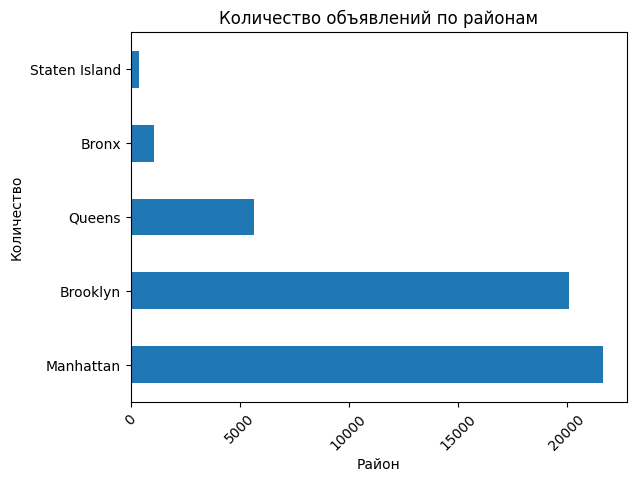

In [10]:
df['neighbourhood_group'].value_counts().plot.barh()
plt.title("Количество объявлений по районам")
plt.xlabel("Район")
plt.ylabel("Количество")
plt.xticks(rotation=45)

plt.show()

Интересно, есть дисбаланс по количествам объявлениям в районах

In [10]:
print('Средняя цена для каждого района:')
df.groupby('neighbourhood_group')['price'].mean()

Средняя цена для каждого района:


neighbourhood_group
Bronx             87.496792
Brooklyn         124.383207
Manhattan        196.875814
Queens            99.517649
Staten Island    114.812332
Name: price, dtype: float64

In [14]:
print(' для каждого района:')
df.groupby('neighbourhood_group')['price'].median()

Медиана для каждого района:


neighbourhood_group
Bronx             65.0
Brooklyn          90.0
Manhattan        150.0
Queens            75.0
Staten Island     75.0
Name: price, dtype: float64

Интересная ситуация у Staten island. В среднем он показал себя неплохо, когда как в медиане он среднячок. Это говорит, что у нас скошенное распределение. Среднее вытянули выбросы и маленькое количество объявлений вовсе. Но тем не менее Манхеттен самый дорогой район, что ожидаемо.

In [12]:
n_kvartals = len(df['neighbourhood'].unique())
print(f'Всего кварталов - {n_kvartals}')

Всего кварталов - 221


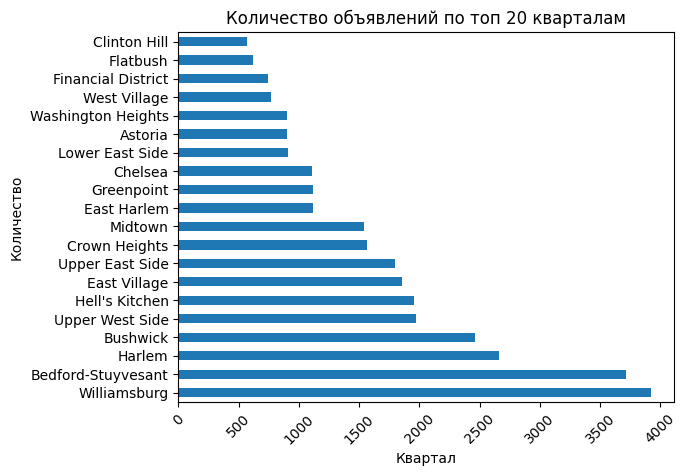

In [18]:
df['neighbourhood'].value_counts().head(20).plot.barh()
plt.title("Количество объявлений по топ 20 кварталам")
plt.xlabel("Квартал")
plt.ylabel("Количество")
plt.xticks(rotation=45)

plt.show()

Кварталов очень много! Плюс также есть дисбалансы между количеством объявлений

In [8]:
df.groupby('neighbourhood').size().sort_values().head(10)

neighbourhood
Rossville         1
Richmondtown      1
Fort Wadsworth    1
Willowbrook       1
New Dorp          1
Woodrow           1
Co-op City        2
West Farms        2
Howland Hook      2
Westerleigh       2
dtype: int64

Рассмотрим room_type

In [2]:
n_room_type = len(df['room_type'].unique())
print(f'Всего типов комнат - {n_room_type}')

Всего типов комнат - 3


In [4]:
df['room_type'].value_counts(normalize=True)

room_type
Entire home/apt    0.519665
Private room       0.456611
Shared room        0.023724
Name: proportion, dtype: float64

In [6]:
print('Средняя цена для каждого типа комнат:')
df.groupby('room_type')['price'].mean()

Средняя цена для каждого типа комнат:


room_type
Entire home/apt    211.794246
Private room        89.780973
Shared room         70.127586
Name: price, dtype: float64

room_type            Entire home/apt  Private room  Shared room
neighbourhood_group                                            
Bronx                          100.0          53.5         40.0
Brooklyn                       145.0          65.0         36.0
Manhattan                      191.0          90.0         69.0
Queens                         120.0          60.0         37.0
Staten Island                  100.0          50.0         30.0



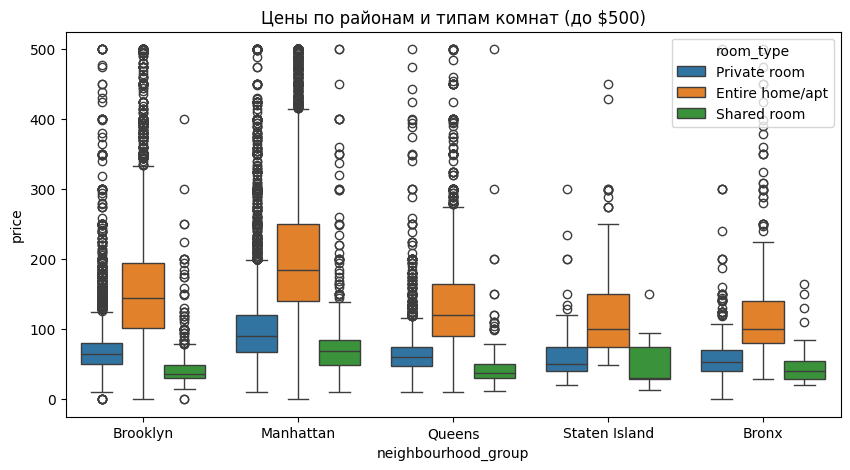

In [4]:
cross = df.groupby(['neighbourhood_group', 'room_type'])['price'].median().unstack()
print(cross)
print()

fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(data=df[df['price'] <= 500], x='neighbourhood_group', y='price', hue='room_type', ax=ax)
ax.set_title('Цены по районам и типам комнат (до $500)')
plt.show()

Снова видим картину, что Манхеттен самый дорогой, а Entire home/apt самый дорогой слот для всех районов. 

Теперь рассмотрим price

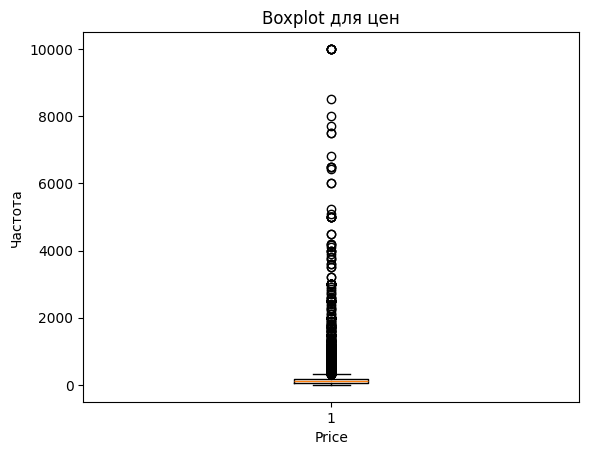

In [4]:
plt.boxplot(df['price'])
plt.title('Boxplot для цен')
plt.xlabel('Price')
plt.ylabel('Частота')
plt.show()

In [32]:
print('Характеристики для цены equal or less than 1000:')

var = df['price'].clip(upper=1000).var()
std = df['price'].clip(upper=1000).std()
skew = df['price'].clip(upper=1000).skew()
kurtosis = df['price'].clip(upper=1000).kurtosis()

print(f'Дисперсия = {var}')
print(f'Стандартное отклонение - {std}')
print(f'Skewness = {skew}')
print(f'Эксцесс = {kurtosis}')

Характеристики для цены equal or less than 1000:
Дисперсия = 17147.90903849956
Стандартное отклонение - 130.95002496563168
Skewness = 3.3570187271944323
Эксцесс = 15.622189267479413


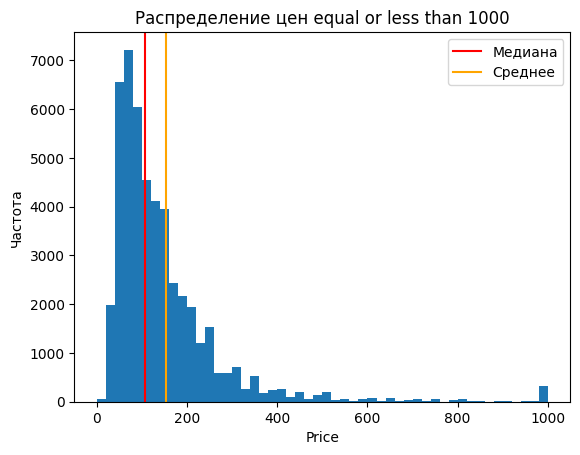

In [34]:
plt.hist(df['price'].clip(upper=1000), bins=50)
plt.axvline(df['price'].median(), color='red', label='Медиана')
plt.axvline(df['price'].mean(), color='orange', label='Среднее')

plt.legend()
plt.title('Распределение цен equal or less than 1000')
plt.xlabel('Price')
plt.ylabel('Частота')
plt.show()

Распределение цен скошено вправо. А это еще не считали выбросы, которые очень сильные. Причем по boxplot можно сказать, что их и не мало. Лучше всего мега выбросы стоит выбросить, потому что смогут тянуть на себя ошибки. Возможно придется логарифмировать.

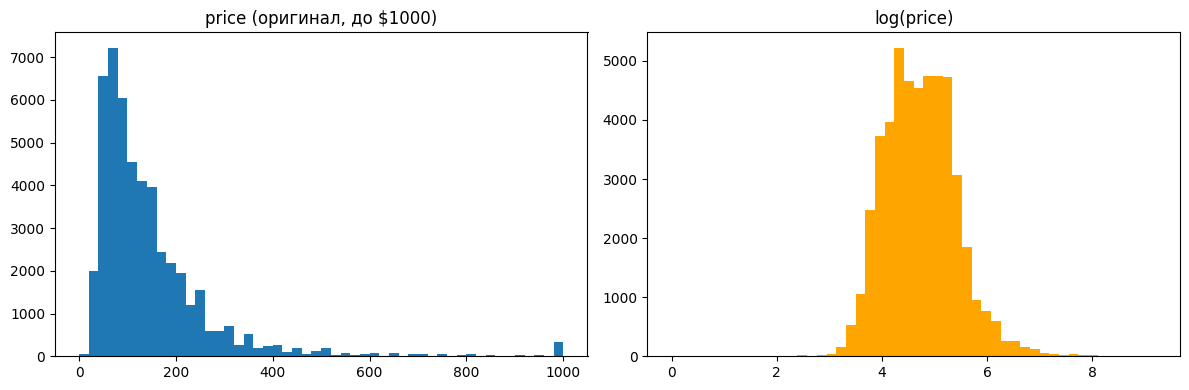

Skewness оригинала: 19.12
Skewness после лога: 0.55


In [6]:
df['log_price'] = np.log1p(df['price'])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df['price'].clip(upper=1000), bins=50)
axes[0].set_title('price (оригинал, до $1000)')

axes[1].hist(df['log_price'], bins=50, color='orange')
axes[1].set_title('log(price)')

plt.tight_layout()
plt.show()

print(f"Skewness оригинала: {df['price'].skew():.2f}")
print(f"Skewness после лога: {df['log_price'].skew():.2f}")

Логарифмирование лучше нормализовала price

Посмотрим на парные зависимости цены от числовых признаков

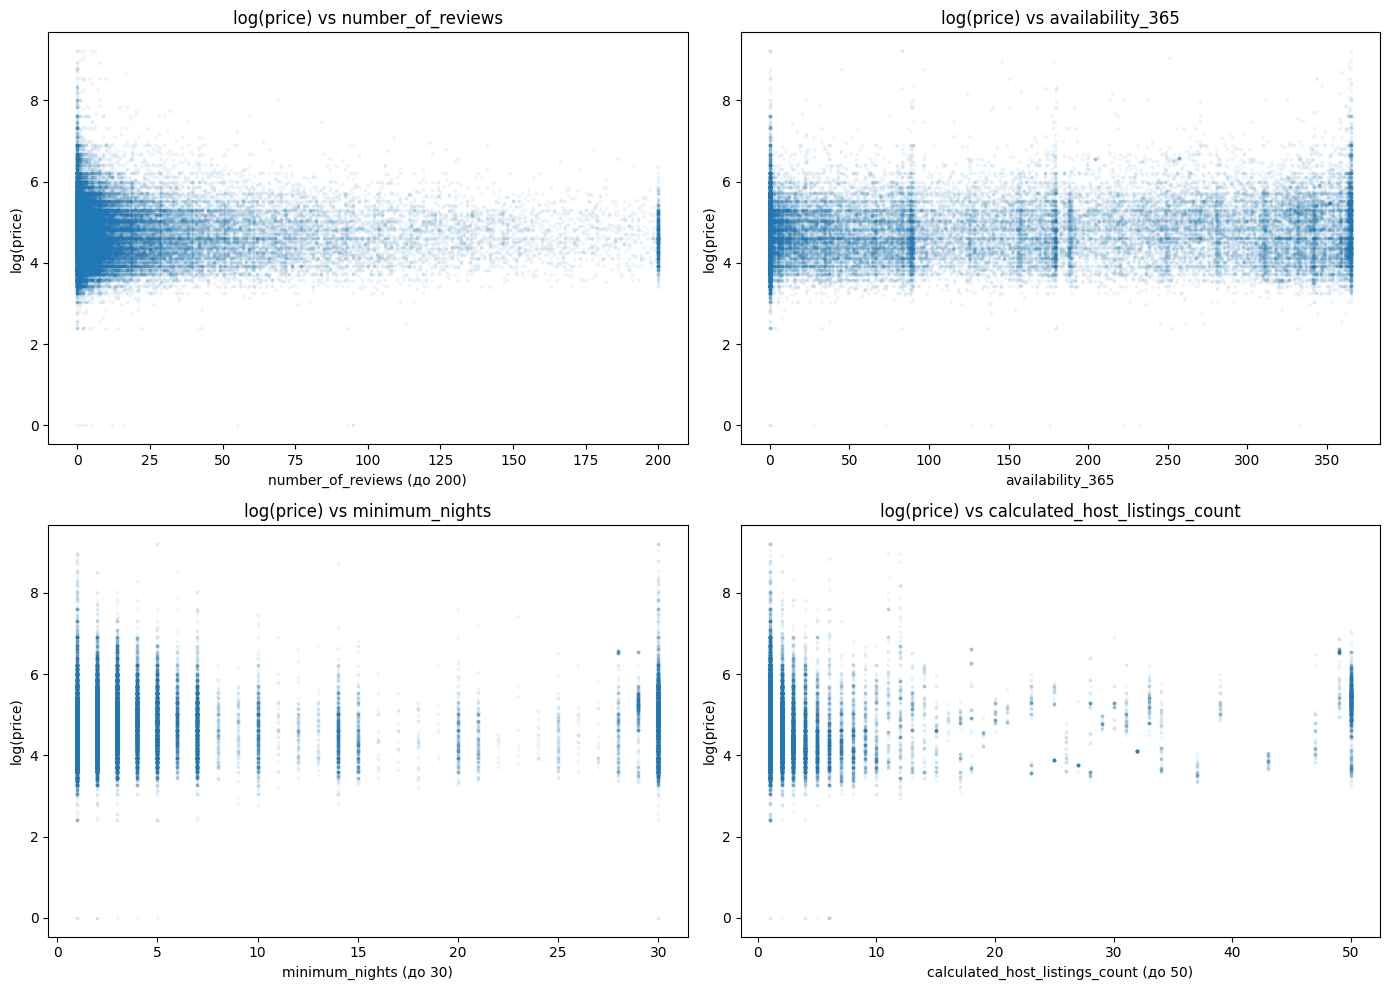

In [2]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# log_price vs number_of_reviews
axes[0, 0].scatter(df['number_of_reviews'].clip(upper=200), df['log_price'], alpha=0.05, s=3)
axes[0, 0].set_xlabel('number_of_reviews (до 200)')
axes[0, 0].set_ylabel('log(price)')
axes[0, 0].set_title('log(price) vs number_of_reviews')

# log_price vs availability_365
axes[0, 1].scatter(df['availability_365'], df['log_price'], alpha=0.05, s=3)
axes[0, 1].set_xlabel('availability_365')
axes[0, 1].set_ylabel('log(price)')
axes[0, 1].set_title('log(price) vs availability_365')

# log_price vs minimum_nights
axes[1, 0].scatter(df['minimum_nights'].clip(upper=30), df['log_price'], alpha=0.05, s=3)
axes[1, 0].set_xlabel('minimum_nights (до 30)')
axes[1, 0].set_ylabel('log(price)')
axes[1, 0].set_title('log(price) vs minimum_nights')

# log_price vs calculated_host_listings_count
axes[1, 1].scatter(df['calculated_host_listings_count'].clip(upper=50), df['log_price'], alpha=0.05, s=3)
axes[1, 1].set_xlabel('calculated_host_listings_count (до 50)')
axes[1, 1].set_ylabel('log(price)')
axes[1, 1].set_title('log(price) vs calculated_host_listings_count')

plt.tight_layout()
plt.show()

Что можно сказать. Во-первых, где отзывы около нуля там наблюдается такой треугольник цен. Чем больше отзывов, тем уже (хоть уже в перспективе диапазон почти один и тот же и не наблюдается какой-то связи). Дорогие объявления менее популярны. Еще большой диапазон у крайних значений availability_365. Линейной связи тоже не наблюдаю. Аналоигчно с остальными. Хотя по количеству у хозяина наблюдается некая тенденция. Чем больше квартир у хозяина, тем больше цены сконцетрированны на одной высоте (а значит в неком узком диапазоне). У тех, у кого 1- 2 квартиры не такая ситуация, они больше разбросаны.

In [18]:
!pip install phik==0.12.5

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 679.0/679.0 kB 8.4 MB/s eta 0:00:00

[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


interval columns not set, guessing: ['latitude', 'longitude', 'price', 'minimum_nights', 'number_of_reviews', 'reviews_per_month', 'calculated_host_listings_count', 'availability_365']
/root/venv/lib/python3.11/site-packages/phik/data_quality.py:59: UserWarning: The number of unique values of variable last_review is large: 1764. Are you sure this is not an interval variable? Analysis for pairs of variables including last_review can be slow.
  warnings.warn(


<function matplotlib.pyplot.show(close=None, block=None)>

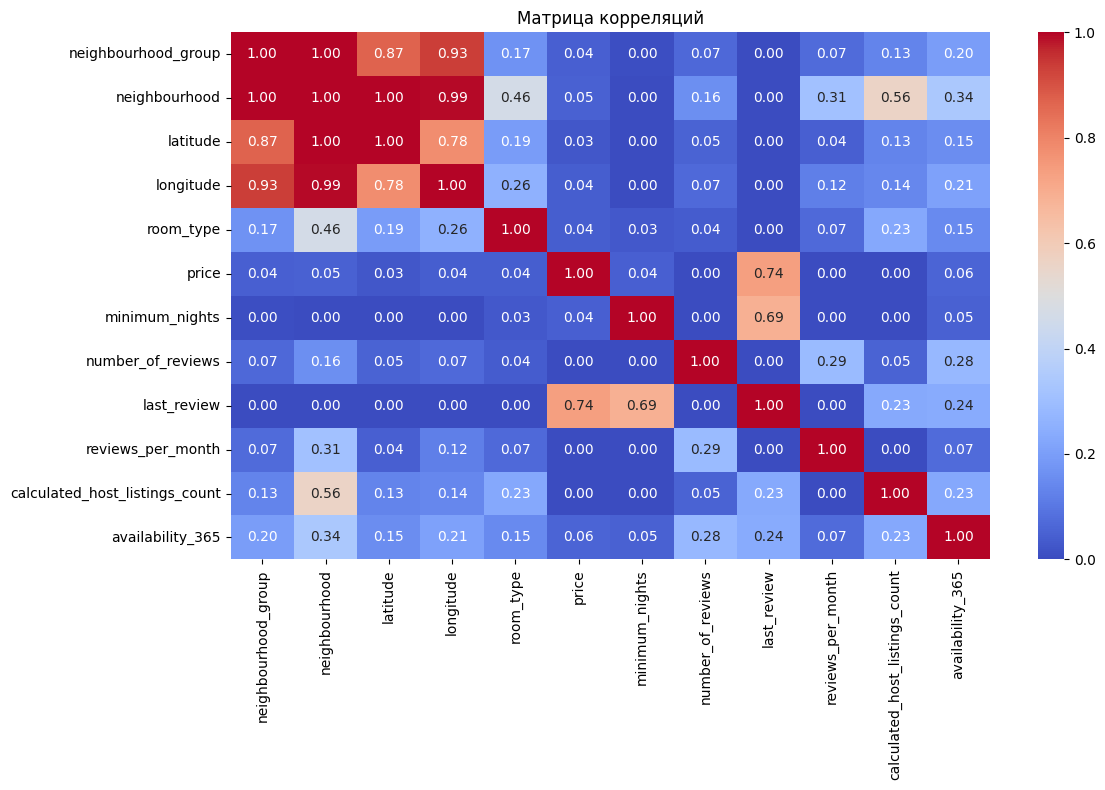

In [22]:
import phik
from phik.report import plot_correlation_matrix

corr_matrix = df.drop(columns=['id', 'host_id', 'name', 'host_name']).phik_matrix()

plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Матрица корреляций')
plt.tight_layout()
plt.show

Посмотрим на зависимость log(price) от некоторых числовых характеристик

Посмотрим на аномальные на наш взгляд значения

In [10]:
checks = {
    'price == 0':               (df['price'] == 0).sum(),
    'price > 1000':             (df['price'] > 1000).sum(),
    'minimum_nights > 365':     (df['minimum_nights'] > 365).sum(),
    'minimum_nights > 30':      (df['minimum_nights'] > 30).sum(),
    'availability_365 == 0':    (df['availability_365'] == 0).sum(),
    'availability_365 == 365':  (df['availability_365'] == 365).sum(),
    'number_of_reviews == 0':   (df['number_of_reviews'] == 0).sum(),
    'number_of_reviews > 100':  (df['number_of_reviews'] > 100).sum(),
}
for k, v in checks.items():
    print(f"{k:<35} {v:>6} ({v/len(df)*100:.2f}%)")

price == 0                              11 (0.02%)
price > 1000                           239 (0.49%)
minimum_nights > 365                    14 (0.03%)
minimum_nights > 30                    747 (1.53%)
availability_365 == 0                17533 (35.86%)
availability_365 == 365               1295 (2.65%)
number_of_reviews == 0               10052 (20.56%)
number_of_reviews > 100               2995 (6.13%)


Оп, есть price = 0. Но этого быть не может, потому что квартиры на airbnb не могут быть бесплатными. Значит эти строки(тем более их мало) удаляем. Плюс ко всему, достаточно необычно для сервиса краткосрочной аренды видеть minimum_night > 30. Лучше такие строчки удалить, чтобы наш датасет отображал типичную картину квартир краткосрочной аренды в NYC. Ещё интересно, что целых 35 процентов availability_365 = 0. Их нельзя спешить удалять. Так же и квартиры с нулем отзывов. 

Внизу показаны сколько выбросов в каждой категории. Больше всего у количества отзывов и минимального количества ночей

In [12]:
for col in ['price', 'minimum_nights', 'number_of_reviews', 'reviews_per_month', 'availability_365']:
    q1, q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    iqr = q3 - q1
    outliers = ((df[col] < q1 - 1.5*iqr) | (df[col] > q3 + 1.5*iqr)).sum()
    print(f"{col:<35} {outliers:>6} ({outliers/len(df)*100:.2f}%)")

price                                 2972 (6.08%)
minimum_nights                        6607 (13.51%)
number_of_reviews                     6021 (12.31%)
reviews_per_month                     1793 (3.67%)
availability_365                         0 (0.00%)


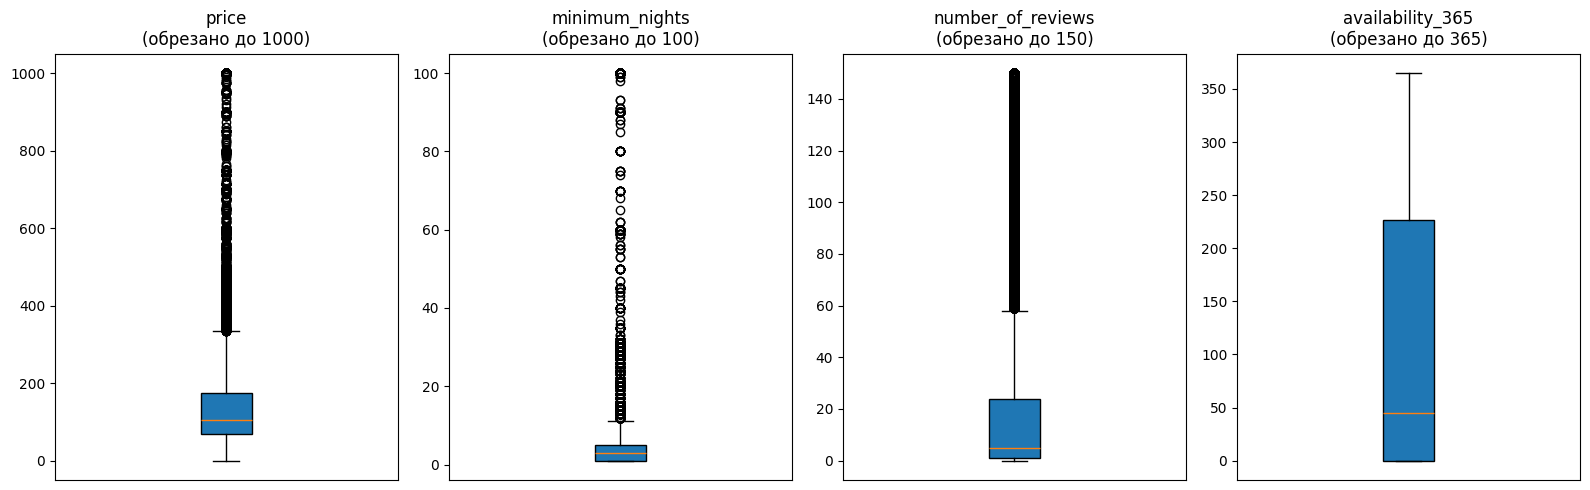

In [14]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 4, figsize=(16, 5))
cols = ['price', 'minimum_nights', 'number_of_reviews', 'availability_365']
clips = [1000, 100, 150, 365]

for ax, col, clip in zip(axes, cols, clips):
    ax.boxplot(df[col].clip(upper=clip), patch_artist=True)
    ax.set_title(f'{col}\n(обрезано до {clip})')
    ax.set_xticks([])

plt.tight_layout()
plt.show()

Любопытно ещё изучить объявления с availability_365 = 0

In [2]:
zero_avail = df[df['availability_365'] == 0]

popular = zero_avail[zero_avail['number_of_reviews'] >= 10]
dead = zero_avail[zero_avail['number_of_reviews'] == 0]
grey = zero_avail[(zero_avail['number_of_reviews'] > 0) & (zero_avail['number_of_reviews'] < 10)]

print(f"Всего availability_365 = 0: {len(zero_avail)}")
print(f"  Популярные (reviews >= 10): {len(popular)} ({len(popular)/len(zero_avail)*100:.1f}%)")
print(f"  Серая зона (reviews 1-9):   {len(grey)} ({len(grey)/len(zero_avail)*100:.1f}%)")
print(f"  Мёртвые (reviews = 0):      {len(dead)} ({len(dead)/len(zero_avail)*100:.1f}%)")

Всего availability_365 = 0: 17533
  Популярные (reviews >= 10): 3369 (19.2%)
  Серая зона (reviews 1-9):   9319 (53.2%)
  Мёртвые (reviews = 0):      4845 (27.6%)


Достаточно много в мертвой зоне. Если честно, даже предположить не могу, что за этим стоит (скорее всего боты). Проще удалить их из-за их сомнительности.

Визуализируем по географическим координатам цены

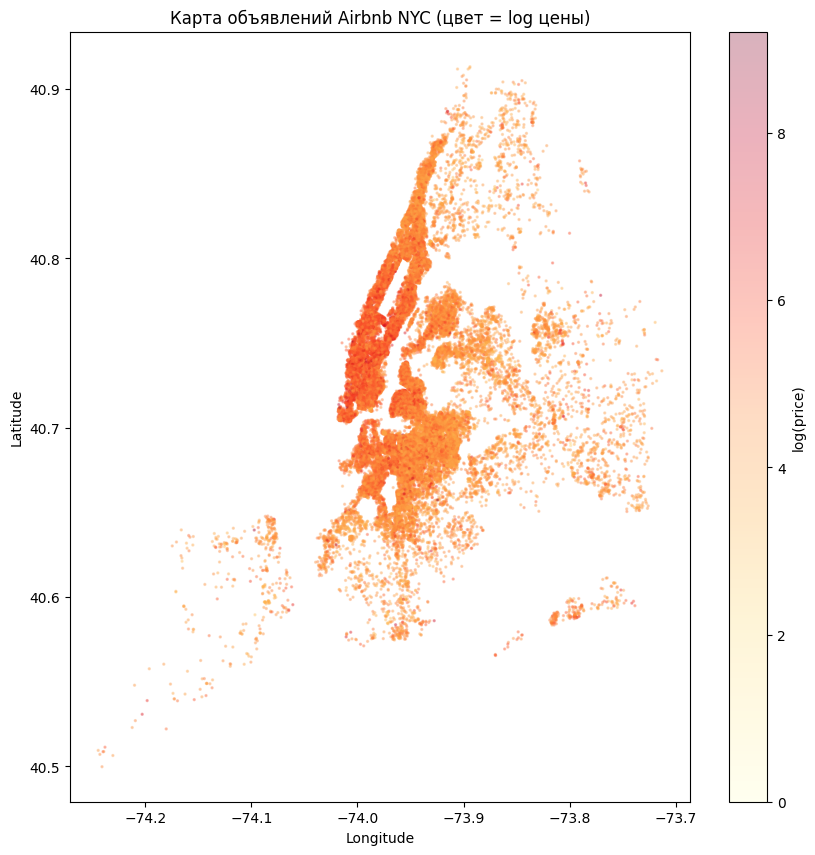

In [8]:
fig, ax = plt.subplots(figsize=(10, 10))
scatter = ax.scatter(df['longitude'], df['latitude'],
                     c=df['log_price'], cmap='YlOrRd',
                     alpha=0.3, s=2)
plt.colorbar(scatter, label='log(price)')
ax.set_title('Карта объявлений Airbnb NYC (цвет = log цены)')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
plt.show()

Хаха, давайте приложим карту настоящего Нью-Йорка. Хотя уже сам график отчетливо показывает очертания.

<img src="image-20260417-153553.png" width="50" align="" />

Теперь мы можем НАГЛЯДНО видеть, что Манхеттен самый дорогой. Популярные районы именно являются Бруклин и Манхеттен. А в Статен-Айленде очень мало объявлений. А ещё есть некая зависимость, что чем ближе к Тайм Сквер, тем правда дороже.

### Выводы по EDA:

- Датасет содержит 48 895 объявлений, дубликатов нет. Пропуски в last_review и reviews_per_month связаны с отсутствием отзывов (10 052 строки), пропуски в name и host_name ничтожны.
- Распределение цен сильно скошено вправо (skewness = 19.12). Логарифмирование снижает skewness до 0.55 — для линейной регрессии следует использовать log(price).
- Цена = 0 (11 строк) — ошибки данных, удаляем. Объявления с minimum_nights > 30 (747 строк) нетипичны для краткосрочной аренды — тоже удаляем. 99,5 процентов имеет цену меньше 1000. Поэтому мне легче удалить экстримальные значения
- Ключевые факторы цены — район (neighbourhood_group) и тип комнаты (room_type). Манхэттен — самый дорогой район, Entire home/apt — самый дорогой тип.
- 35.86% объявлений имеют availability_365 = 0. Из них ~19% — популярные (10+ отзывов), ~28% — мёртвые (0 отзывов), остальные — серая зона. Удалять всё нельзя, но стоит учитывать этот нюанс при моделировании. Мертвых однако стоит удалить, они слишком сомнительные
- Хозяева с большим количеством объявлений (calculated_host_listings_count) показывают более стабильные цены в среднем-верхнем диапазоне — это профессиональные арендодатели. Признак может быть полезен для модели.
- number_of_reviews отрицательно связан с ценой: дешёвые объявления бронируются чаще и получают больше отзывов.
- Географический scatter plot подтверждает зависимость цены от расположения — центр Манхэттена заметно дороже. На этапе feature engineering имеет смысл создать признак расстояния до центра.
- Корреляционная матрица (phik) показывает сильную связь между географическими признаками (neighbourhood_group, neighbourhood, latitude, longitude) и слабую связь price с большинством других переменных. Я приму решение пока что удалить neighbourhood и оставить neighbourhood_group из-за высокой вероятности переобучение (в некоторых районах правда очень мало квартир, а то и одна квартира)

## Preprocessing до разделения на train test выборки

### Заполнение пропусков

Пропуски у нас есть лишь в last_review и review_per_month. Мы знаем, что это связано с тем, что квартиры имеют ноль отзывов. Тогда логично заполнить пропуски в review_per_month нулем, а last_review датой как можно раньше. В EDA мы выяснили, что "Даты лежат в диапазоне 2011-03-28 00:00:00 - 2019-07-08 00:00:00". Поставлю дату  2006-01-25, в честь моего дня рождения:)

In [108]:
df['last_review'] = df['last_review'].fillna('2006-01-25')
df['reviews_per_month'] = df['reviews_per_month'].fillna(0)

### Очистка от ненужных фичей и всяких ошибок с выбросами.

Отсеку по 99 квантилю цену. Бесплатные квартиры тоже удалю. Мертвые объявления тоже. A minimum_nights решила на равном 30. Обоснованно тем, что больше одного месяца уже является другим сегментом рынка

In [110]:
upper = df['price'].quantile(0.99)
print(f"99-й перцентиль: ${upper}")

99-й перцентиль: $799.0


In [112]:
df_clean = df[
    (df['minimum_nights'] <= 30) &
    (df['price'] > 0) &
    (df['price'] <= df['price'].quantile(0.99)) &
    ((df['availability_365'] > 0) | (df['number_of_reviews'] > 0))
]

df_clean = df_clean.drop(columns=['host_id', 'id', 'host_name', 'name', 'neighbourhood'])

### Feature Engineiring

#### Фича log_price (ln(price + 1) (ну я очистила конечно цены равные нулю, но вообще это полезная привычка, чтобы не было краша программы)
P.S надо будет удалить price. Метрики при обучении модели будем проверять на np.expm1(log_price)

In [114]:
df_clean['log_price'] = np.log1p(df_clean['price'])
df_clean = df_clean.drop(columns=['price'])

#### Фича dist_to_center (расстояние квартиры до центра Тайм Сквер)

P.S после этого надо будет удалить колонки longitude latitude

In [116]:
from math import radians, sin, cos, sqrt, atan2

# считаем по формуле хаверсина
def haversine(lat1, lon1, lat2, lon2):
    R = 6371  # радиус Земли в км
    dlat = radians(lat2 - lat1)
    dlon = radians(lon2 - lon1)
    a = sin(dlat/2)**2 + cos(radians(lat1)) * cos(radians(lat2)) * sin(dlon/2)**2
    return R * 2 * atan2(sqrt(a), sqrt(1 - a))

#координаты центра
TS_LAT, TS_LON = 40.7580, -73.9855

df_clean['distance_to_times_sq'] = df_clean.apply(
    lambda row: haversine(row['latitude'], row['longitude'], TS_LAT, TS_LON), axis=1
)

df_clean['distance_to_times_sq'].describe()

count    42986.000000
mean         7.224910
std          4.505907
min          0.068492
25%          3.892307
50%          6.578389
75%          9.520576
max         35.898255
Name: distance_to_times_sq, dtype: float64

In [118]:
df_clean = df_clean.drop(columns=['longitude', 'latitude'])

Посмотри зависимость этой фичи от цены

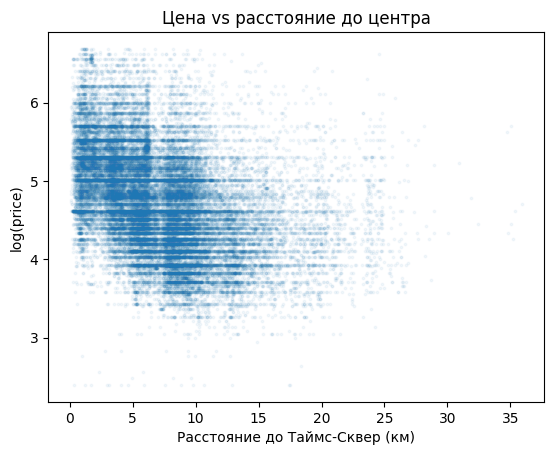

In [120]:
plt.scatter(df_clean['distance_to_times_sq'], df_clean['log_price'], alpha=0.05, s=3)
plt.xlabel('Расстояние до Таймс-Сквер (км)')
plt.ylabel('log(price)')
plt.title('Цена vs расстояние до центра')
plt.show()

In [49]:
print(f"Корреляция distance_to_times_sq и log_price: {df_clean['distance_to_times_sq'].corr(df_clean['log_price']):.3f}")

Корреляция distance_to_times_sq и log_price: -0.400


Корреляция с ценой прослеживается (чем меньше расстояние, тем больше цена). Большинство объявлений ближе к центру, что неудивительно. Есть даже буквально в тайм сквер (68 метров). Облако точек наклонено вниз право, что говорит о том, что диапазон в основном сдвинут верх, чем ближе к центру.

#### Фича day_since_last_review (сколько дней прошло с дня последнего интервью)

P.S после этого я удалю колонку last_review, так как эти две колонки очевидно коррелированные

In [122]:
max_date = pd.to_datetime(df_clean['last_review']).max()
df_clean['day_since_last_review'] = (max_date - pd.to_datetime(df['last_review'])).dt.days
df_clean = df_clean.drop(columns=['last_review'])

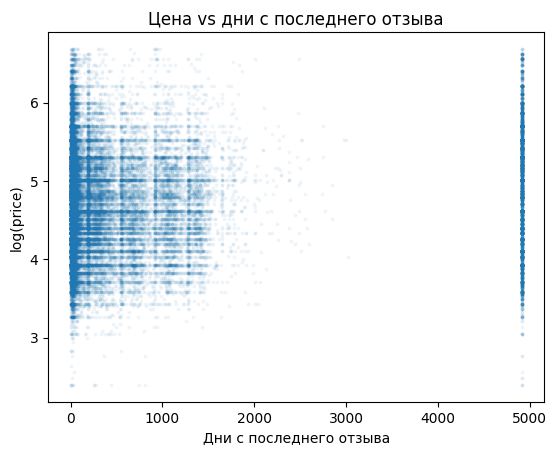

In [101]:
plt.scatter(df_clean['day_since_last_review'], df_clean['log_price'], alpha=0.05, s=3)
plt.xlabel('Дни с последнего отзыва')
plt.ylabel('log(price)')
plt.title('Цена vs дни с последнего отзыва')
plt.show()

In [103]:
print(f"Корреляция с day_since_last_review и log_price: {df_clean['day_since_last_review'].corr(df_clean['log_price']):.3f}")

Корреляция с day_since_last_review и log_price: 0.098


In [105]:
print(f"Корреляция с day_since_last_review (без пропусков то есть < 4000) и log_price: {df_clean[df_clean['day_since_last_review'] < 4000]['day_since_last_review'].corr(df_clean[df_clean['day_since_last_review'] < 4000]['log_price']):.3f}")

Корреляция с day_since_last_review (без пропусков то есть < 4000) и log_price: -0.010


Корреляция слабенькая, но все равно хочу взять этот признак. Может быть кстати сужается диапазон с более старым отзывом. А так для объявлений без отзыва диапазон достаточно широкий. Линейной связи нету.

## Preprocessing после разделения на test train выборки

In [124]:
seed = 45

Разделим данные на X (фичи) и Y (таргет)

In [126]:
X = df_clean.drop(columns=['log_price'])
y = df_clean['log_price']

In [128]:
X.tail(5)

,neighbourhood_group,room_type,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365,distance_to_times_sq,day_since_last_review
48890,Brooklyn,Private room,2,0,0.0,2,9,9.330755,4912
48891,Brooklyn,Private room,4,0,0.0,2,36,7.644594,4912
48892,Manhattan,Entire home/apt,10,0,0.0,1,27,7.030987,4912
48893,Manhattan,Shared room,1,0,0.0,6,2,0.476484,4912
48894,Manhattan,Private room,7,0,0.0,1,23,0.745067,4912


Сначала разделим данные на train и test. Я сначала разделю диапазон на бины и потом сделаю так, чтобы в обучающей и тестовой выборке были одинаковые пропорции бинов. Специально так делаю, чтобы и там, и там, были и дешевые, и дорогие квартиры разного сегмента.

In [130]:
from sklearn.model_selection import train_test_split

bins = pd.qcut(y, q=7, labels=False)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=seed, stratify=bins)

### Обработка категориальных признаков

Надо теперь обработать категориальные признаки. В признаках, где числа, все-таки числовые, нельзя их как категориальные признаки(А вот если было типо размер 0, 1, 2, то можно было бы обработаь как категориальный признак)

In [140]:
categorical_features = X.select_dtypes(['object'])
print(categorical_features.columns)

Index(['neighbourhood_group', 'room_type'], dtype='object')


Мы видим лишь два категориальных признака: район и тип комнаты:
- район лучше всего закодировать как one hot encoding. Действительно от района к району медиана слишком разная. Значения этого признака мало, поэтому это хорошая идея.
- Тип комнаты закодируем как One Hot Encoding, ведь label encoding не подходит из-за ложной построения иеархии.Значений признака вообще 3, так что немного будет столбцов

In [144]:
from sklearn.preprocessing import OneHotEncoder

one_hot_encoding_features = ['room_type', 'neighbourhood_group']

ohe = OneHotEncoder(drop='first', sparse_output=False).set_output(transform='pandas')
#фит по обучающей выборке
ohe.fit(X_train[one_hot_encoding_features])

train_encoded = pd.DataFrame(
    ohe.transform(X_train[one_hot_encoding_features]),
    columns=ohe.get_feature_names_out(),
    index=X_train.index
)

test_encoded = pd.DataFrame(
    ohe.transform(X_test[one_hot_encoding_features]),
    columns=ohe.get_feature_names_out(),
    index=X_test.index
)

X_train = X_train.drop(columns=one_hot_encoding_features).join(train_encoded)
X_test = X_test.drop(columns=one_hot_encoding_features).join(test_encoded)

### Обработка числовых признаков (для Линейной регрессии в будущем)

In [174]:
numerical_features = X.select_dtypes(['int64', 'float64']).columns
print(numerical_features)

Index(['minimum_nights', 'number_of_reviews', 'reviews_per_month',
       'calculated_host_listings_count', 'availability_365',
       'distance_to_times_sq', 'day_since_last_review'],
      dtype='object')


Для числовых признаков при линейной регрессии лучше всего использовать StandardScaler. Он делает так, чтобы выборочное среднее было 0, а дисперсия 1

In [176]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train[numerical_features] = scaler.fit_transform(X_train[numerical_features])
X_test[numerical_features] = scaler.transform(X_test[numerical_features])

## Итоговые выводы

### Что я поняла про датасет

- Датасет содержит 48 895 объявлений Airbnb в Нью-Йорке (2019). Дубликатов нет, но есть пропуски в `last_review` и `reviews_per_month` — они полностью объясняются отсутствием отзывов (number_of_reviews = 0).
- Распределение цен сильно скошено вправо (skewness = 19.12). Логарифмирование снижает skewness до 0.55 — значит, для линейной регрессии стоит использовать `log(price)` как таргет.
- Самый дорогой район — Манхэттен (медиана $150), самый дешёвый — Бронкс (медиана $65). Самый дорогой тип жилья — Entire home/apt, и это справедливо для всех районов.
- 35.86% объявлений имеют `availability_365 = 0` (из-за этого я не удалила это, хоть и выглядят такие объявления как фиктивные). Среди них ~28% — «мёртвые» (ноль отзывов + закрытый календарь), то есть неактивные объявления, которые не участвуют в реальном рынке.
- Есть 11 объявлений с price = 0 — это явные ошибки данных, им нечего делать в датасете.
- Кварталов 221, и распределение объявлений по ним крайне неравномерное: есть кварталы с одним объявлением. Это делает `neighbourhood` опасным признаком для модели — проще его убрать, чем бороться с переобучением.
- `calculated_host_listings_count` совпадает с реальным количеством объявлений у хозяина в датасете, то есть его можно использовать вместо `host_id`.
- Хозяева с большим числом объявлений (профессиональные арендодатели) ставят более стабильные цены в среднем-верхнем диапазоне.
- Расстояние до Таймс-Сквер показало самую сильную корреляцию с log(price) среди числовых признаков (−0.4). Географическая карта это подтверждает визуально.
- Числовые признаки (reviews, availability, minimum_nights) слабо коррелируют с ценой по отдельности. Основные предикторы цены — это локация и тип жилья. Сильно коррелирует last_review, но тут скорее это объясняется, что 

### Гипотезы и наблюдения

1. **Район и тип жилья — главные драйверы цены.** Комбинация `neighbourhood_group` + `room_type` объясняет большую часть вариации. Числовые признаки добавляют мало, потому что рынок аренды в первую очередь определяется расположением.
2. **Объявления с `minimum_nights > 30` — это по сути долгосрочная аренда**, другой сегмент рынка с другим ценообразованием. Их удаление делает датасет более однородным и модель — более точной для задачи краткосрочной аренды.
3. **Выбросы по цене — не ошибки, а luxury-сегмент.** Квартиры за $5000–10000 реально существуют на Airbnb, но их ценообразование работает иначе (бренд, уникальность, вид из окна). Линейная модель не сможет их предсказать, поэтому обрезка по 99-му перцентилю оправдана.
4. **Дешёвые объявления бронируются чаще** — об этом говорит облако точек «цена vs отзывы»: чем больше отзывов, тем ниже цена в среднем. Дорогие квартиры бронируют реже, отзывов у них меньше.
5. **Закрытый календарь (availability = 0) при наличии отзывов** — это скорее всего сезонные хозяева, которые сдают квартиру только в определённые месяцы и потом закрывают бронирование. Удалять их не стоит — это реальные участники рынка.

### Что бы я сделала дальше

- Обучила бы линейную регрессию на подготовленных данных и посмотрела на метрики (RMSE, MAE, R²) на тестовой выборке. Метрики надо считать на `np.expm1(log_price)`, чтобы вернуться к реальным долларам. Но мне кажется, что нелинейные модели покажут себя лучше, ведь зависимость цены от некоторых фич далеко не линейная.
- Попробовала бы Ridge или Lasso — они могут справиться лучше, если есть лишние признаки (например, `day_since_last_review` со слабой корреляцией).
- Посмотрела бы на коэффициенты модели — какие признаки оказались важными, совпадает ли это с EDA.
- Попробовала бы дерево решений или случайный лес для сравнения — им не нужна нормализация и они могут ловить нелинейные зависимости.
- Посмотрела бы residuals — где модель ошибается сильнее всего (может быть, в определённых районах или ценовых сегментах).

## Какие подсказки брала у AI и что проверяла/дописывала руками

- Спрашивала у AI, как правильно посчитать корреляцию phik и построить heatmap — адаптировала под свой датасет.
- Формулу Хаверсина для расчёта расстояния до Таймс-Сквер взяла из подсказки AI. А так идея использовать в качестве фичи расстояние сама придумала
- Идею стратифицированного split по бинам цены подсмотрела у AI — проверила руками, что пропорции действительно совпадают в train и test. Но вообще я работала с датасетами классификации, где стратификация более очевидная, поэтому задумалсь о том, почему бы также 'равномерно' разделить датасет.
- EDA, выводы, решения об удалении строк и выборе признаков — делала сама, AI использовала для проверки своих рассуждений (и мою трезвость если честно хд).
- AI помог сформулировать итоговые выводы и оформить итоговые вывод, но все наблюдения основаны на моём собственном анализе в ноутбуке.